<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning
Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that allow us to learn from our data and make any predicitons or decisions without explicitly programming it. 

Machine learning can identify patterns across large datasets that is impossible for the human to do so efficiently. The machine's performance can also be improved over time as they are more exposed to more data or by fine-tuning certain parameters.

## Load all relevant artifacts

In [ ]:
import joblib
import torch

# Load train-test split
x_train = joblib.load(r"..\Artifacts\x_train.pkl")
x_test = joblib.load(r"..\Artifacts\x_test.pkl")
y_train = joblib.load(r"..\Artifacts\y_train.pkl")
y_test = joblib.load(r"..\Artifacts\y_test.pkl")
class_names = joblib.load(r"..\Artifacts\class_names.pkl")

print("Data split loaded")

# Load Naive Bayes
rf_model = joblib.load(r"..\Artifacts\random_forest_model.pkl")
rf_vectorizer = joblib.load(r"..\Artifacts\random_forest_vectorizer.pkl")


print("RF model loaded")
print("RF Vectorizer loaded")

Data split loaded
RF model loaded
RF Vectorizer loaded


### Classifier Report Function

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt

def Classifier(
    model=None,
    mode="train",
    model_path="model.pkl",
    vectorizer_path="vectorizer.pkl"
):
    """
    mode="train" -> train model and save model + vectorizer
    mode="load"  -> load saved model + vectorizer, no retraining
    """

    if mode == "train":
        # Create and fit TF-IDF vectorizer on training data only
        vectorizer = TfidfVectorizer()
        x_train_vecs = vectorizer.fit_transform(x_train)
        x_test_vecs = vectorizer.transform(x_test)

        model.fit(x_train_vecs, y_train)

        # Save trained model and fitted vectorizer
        joblib.dump(model, model_path)
        joblib.dump(vectorizer, vectorizer_path)

        print(f"Saved model to: {model_path}")
        print(f"Saved vectorizer to: {vectorizer_path}")

    elif mode == "load":
        # Load saved model and fitted vectorizer
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)

        # Transform test text using loaded vectorizer
        x_test_vecs = vectorizer.transform(x_test)

        print(f"Loaded model from: {model_path}")
        print(f"Loaded vectorizer from: {vectorizer_path}")

    else:
        raise ValueError("Mode must be 'train' or 'load'")

    y_pred = model.predict(x_test_vecs)

    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    sb.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap=None,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return model, vectorizer, y_pred

### **Random Forrest**

Random Forest Classifier is an ensemble learning technique for classification tasks, which builds multiple decision trees and outputs the mode of the classes predicted by individual trees. It's effective, versatile, and resistant to overfitting. The model shows good results in prediction of cyberbullying type in our tweets.

Saved model to: .\Artifacts\random_forest_model.pkl
Saved vectorizer to: .\Artifacts\random_forest_vectorizer.pkl
Accuracy: 0.810

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1952
           1       0.98      0.98      0.98      1995
           2       0.90      0.83      0.86      1952
           3       0.57      0.46      0.51      2040
           4       0.53      0.67      0.59      2006
           5       0.95      0.95      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.82      0.81      0.81     11923
weighted avg       0.81      0.81      0.81     11923



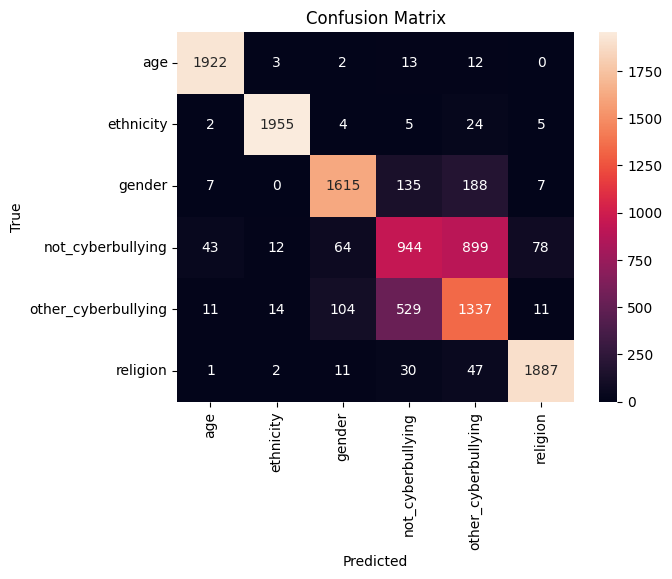

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier model pass it to the Classifier function
model=RandomForestClassifier()

rf_model, rf_vectorizer, rf_y_pred = Classifier(
    model=RandomForestClassifier(random_state=5),
    mode="train",
    model_path=r".\Artifacts\random_forest_model.pkl",
    vectorizer_path=r".\Artifacts\random_forest_vectorizer.pkl"
)

**ROC Curve**

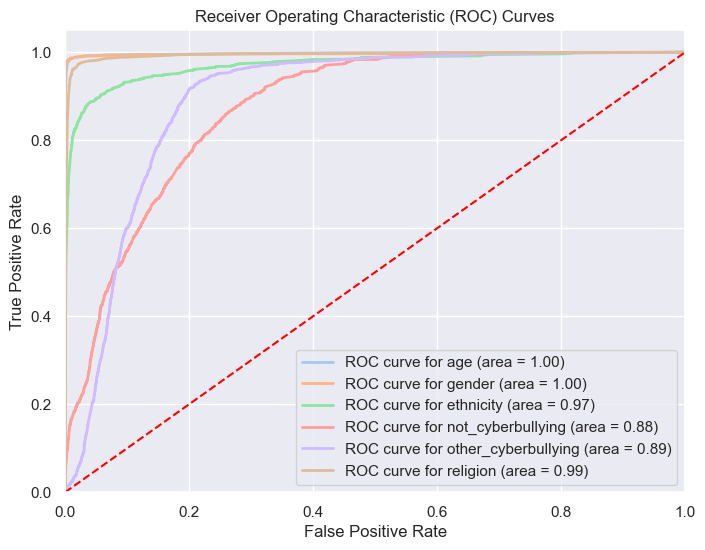

In [ ]:
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

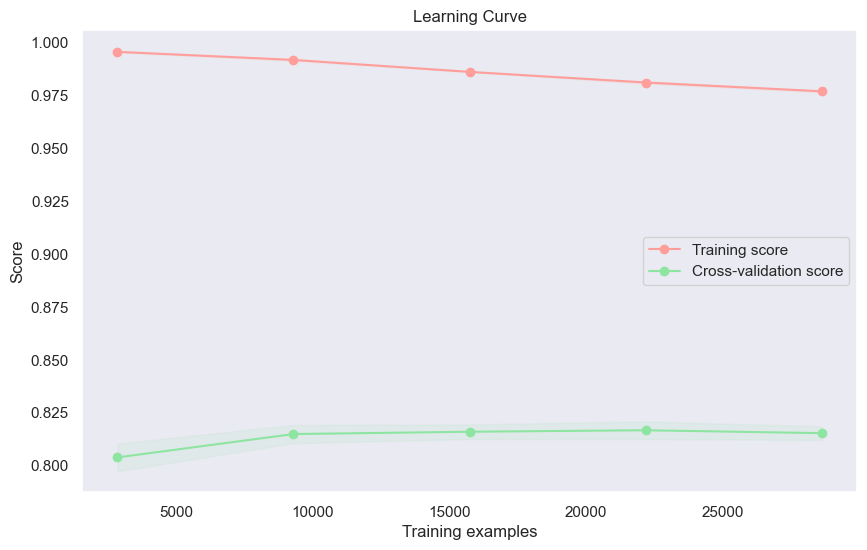

In [ ]:
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Often produces highly accurate predictions, even without extensive hyperparameter tuning.

- By aggregating predictions from multiple decision trees, Random Forest is less prone to overfitting compared to individual decision trees.

- Random Forest can efficiently handle large datasets with many features and instances, making it suitable for complex problems.

- Can handle missing values in the dataset without the need for imputation, reducing preprocessing requirements.

*DISADVANTAGES*

- The ensemble nature of it makes it less interpretable compared to simpler models, as it's challenging to trace predictions back to individual trees.

- Training this model can be computationally expensive, especially for large datasets with numerous trees and deep trees.

- Random Forest tends to be biased towards the majority class in imbalanced datasets, potentially leading to suboptimal performance for minority classes.